## RQ 3 Observation 3.1

In [39]:
# === Build dataset for Observation 3.1: Entry vs. Current State (FIXED) ===
# - Normalizes miner emulator subtypes to legacy categories:
#     Emu_ReactiveCircus/Emu_Malinskiy/Emu_Other -> Emu_Community
#     Emu_DIY                                     -> Emu_Custom
# - Keeps ≥14-day persistence rule for "first" and "current".
# - Outputs: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_1_entry_vs_current.csv

from __future__ import annotations
import json
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple, Set
import pandas as pd

# ---- Paths (must match your miner config) ----
WORK_ROOT   = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT / "mineV9.0"

# Output folder
OBS_OUTPUT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations")
OBS_OUTPUT.mkdir(parents=True, exist_ok=True)

# ---- Constants / settings ----
CUTOFF_ISO   = "2025-08-10 23:59:59 +0000"  # must match miner
PERSIST_DAYS = 14.0

# Legacy categories expected by your analysis
LEGACY_STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")

# Miner → Legacy rollup
EMU_COMMUNITY_SUBTYPES: Set[str] = {"Emu_ReactiveCircus", "Emu_Malinskiy", "Emu_Other"}
EMU_CUSTOM_SUBTYPES:    Set[str] = {"Emu_DIY"}

def normalize_styles(style_set: Set[str]) -> Set[str]:
    """
    Map miner's labels to legacy buckets used by Obs 3.1.
      - community subtypes -> Emu_Community
      - DIY                -> Emu_Custom
      - pass through: GMD, ThirdParty
      - (Optional) keep Real_Device if you want to analyze it; currently ignored
    """
    out: Set[str] = set()
    if style_set & EMU_COMMUNITY_SUBTYPES:
        out.add("Emu_Community")
    if style_set & EMU_CUSTOM_SUBTYPES:
        out.add("Emu_Custom")
    if "GMD" in style_set:
        out.add("GMD")
    if "ThirdParty" in style_set:
        out.add("ThirdParty")
    # If you need Real_Device in outputs, uncomment:
    # if "Real_Device" in style_set:
    #     out.add("Real_Device")
    return out

# ---- Helpers ----
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    """Parse ISO strings that may contain 'Z' or '+0000' endings into aware UTC datetimes."""
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    # Handle "+0000" (no colon)
    if len(s) >= 5 and (s[-5] in ["+", "-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, f"Bad CUTOFF_ISO: {CUTOFF_ISO}"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def label_from_set(style_set: Set[str]) -> str:
    """
    Reduce a normalized styles set to a single label for reporting.
    Priority: Both (Community+Custom) > Community > Custom > GMD > ThirdParty > None
    """
    if "Emu_Community" in style_set and "Emu_Custom" in style_set:
        return "Both"
    if "Emu_Community" in style_set:
        return "Community"
    if "Emu_Custom" in style_set:
        return "Custom"
    if "GMD" in style_set:
        return "GMD"
    if "ThirdParty" in style_set:
        return "ThirdParty"
    return "None"

def read_repo_jsons(output_dir: Path) -> List[Path]:
    return sorted([p for p in output_dir.glob("*.emulator_timeline.json") if p.name not in {"index_summary.json"}])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """
    Convert miner timeline rows into contiguous episodes with {start, end, styles, duration_days}.
    Only keeps episodes whose normalized styles intersect legacy categories (so we ignore empty/irrelevant rows).
    """
    rows = sorted(
        (r for r in timeline_rows if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    episodes: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        raw_styles_set = set(r.get("styles") or [])
        styles_set = normalize_styles(raw_styles_set)
        if not styles_set:
            # Skip rows that don't map to legacy categories
            continue

        # The episode ends when the next (kept) row starts; otherwise at cutoff
        # Find the next row that *also* maps to legacy categories to be a true boundary
        end: Optional[datetime] = None
        for j in range(i + 1, len(rows)):
            nxt = rows[j]
            nxt_styles = normalize_styles(set(nxt.get("styles") or []))
            if nxt_styles:
                end = parse_iso(nxt.get("date"))
                break
        if end is None:
            end = cutoff_dt
        end = end or cutoff_dt

        if end <= start:
            continue

        episodes.append({
            "start": start,
            "end": min(end, cutoff_dt),
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, min(end, cutoff_dt))),
        })
    return episodes

def first_active_label(episodes: List[Dict], min_days: float) -> Tuple[Optional[datetime], str, Set[str]]:
    """
    First episode meeting ≥ min_days. Returns (first_date, label, styles_set).
    Only considers normalized legacy styles.
    """
    eligible = [ep for ep in episodes if ep["duration_days"] >= min_days and any(s in LEGACY_STYLES for s in ep["styles"])]
    if not eligible:
        return None, "None", set()
    earliest = min(eligible, key=lambda ep: ep["start"])
    return earliest["start"], label_from_set(earliest["styles"]), earliest["styles"]

def current_active_label_at_cutoff(episodes: List[Dict], cutoff_dt: datetime, min_days: float) -> Tuple[str, Set[str]]:
    """
    Episode covering the cutoff (last episode) with duration ≥ min_days; else 'None'.
    """
    if not episodes:
        return "None", set()
    last = episodes[-1]
    if last["end"] < cutoff_dt:
        return "None", set()
    if last["duration_days"] >= min_days:
        return label_from_set(last["styles"]), last["styles"]
    return "None", set()

# ---- Build the dataset ----
records: List[Dict] = []

json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSON files found under: {OUTPUT_MINE}")

for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        rec = json.load(f)

    repo = rec.get("repo_name") or jf.stem
    timeline = rec.get("timeline") or []

    episodes = build_episodes(timeline, CUTOFF_DT)
    first_dt, first_label, first_styles = first_active_label(episodes, PERSIST_DAYS)
    current_label, current_styles = current_active_label_at_cutoff(episodes, CUTOFF_DT, PERSIST_DAYS)

    # Also normalize the cutoff snapshot for a quick sanity check (optional diagnostics)
    snapshot_raw = set(rec.get("snapshot_as_of_cutoff") or [])
    snapshot_norm = normalize_styles(snapshot_raw)

    out = {
        "repo_name": repo,
        "cutoff_date": CUTOFF_ISO,

        # First adoption (after ≥14d persistence)
        "first_date": first_dt.isoformat() if first_dt else "",
        "first_year": first_dt.year if first_dt else "",
        "first_label": first_label,                                  # Community / Custom / GMD / ThirdParty / Both / None
        "first_styleset": "+".join(sorted(first_styles)) if first_styles else "",

        # Current state at cutoff (episode that reaches cutoff, ≥14d)
        "current_label": current_label,                              # Community / Custom / GMD / ThirdParty / Both / None
        "current_styleset": "+".join(sorted(current_styles)) if current_styles else "",

        # Optional diagnostics
        "num_episodes": len(episodes),
        "snapshot_norm_at_cutoff": "+".join(sorted(snapshot_norm)) if snapshot_norm else "",
        "qa_issue": rec.get("qa_issue", ""),
    }
    records.append(out)

df = pd.DataFrame.from_records(records).sort_values(["first_date", "repo_name"], na_position="last")

# Save
out_csv = OBS_OUTPUT / "obs3_1_entry_vs_current.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[ok] Wrote dataset: {out_csv}")

# Quick preview (safe in notebooks; harmless in scripts)
try:
    display_cols = ["repo_name","first_year","first_label","current_label","first_date","current_styleset","snapshot_norm_at_cutoff"]
    print(df[display_cols].head(20).to_string(index=False))
except Exception:
    pass


[ok] Wrote dataset: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_1_entry_vs_current.csv
                               repo_name first_year first_label current_label                first_date current_styleset snapshot_norm_at_cutoff
          Criptext__Android-Email-Client                   None          None                                                                   
              CypherpunkArmory__UserLAnd                   None          None                                                                   
                 ICBNetwork__web3-Wallet                   None          None                                                                   
                      agoda-com__ninjato                   None          None                                                                   
             cuongpm__youtube-dl-android                   None          None                                                                   


## RQ3 - F2

In [4]:
# === Observation 3.2 — Historical Trends in Environment Adoption ===
# Builds monthly prevalence (all & env-capable) and entries/exits/net flows by style.
# Reads mined JSONs from Step2 and writes outputs to the requested Observations folder.

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone, timedelta
from typing import Dict, List, Optional, Set, Tuple
import json
import pandas as pd
import math

# -------- Paths --------
# (1) Where your miner wrote JSONs
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.0"

# (2) Where to save Obs 3.2 outputs
OBS_OUT = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations")
OBS_OUT.mkdir(parents=True, exist_ok=True)

# -------- Settings --------
CUTOFF_ISO = "2025-08-10 23:59:59 +0000"  # must match miner
PERSIST_DAYS = 14.0
STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")  # base styles we track
FREQ = "MS"  # monthly (Month Start)

# -------- Helpers --------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    # handle +0000 -> +00:00
    if len(s) >= 5 and (s[-5] in ["+", "-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def label_from_set(style_set: Set[str]) -> str:
    if "Emu_Community" in style_set and "Emu_Custom" in style_set:
        return "Both"
    if "Emu_Community" in style_set:
        return "Community"
    if "Emu_Custom" in style_set:
        return "Custom"
    if "GMD" in style_set:
        return "GMD"
    if "ThirdParty" in style_set:
        return "ThirdParty"
    return "None"

def read_repo_jsons(output_dir: Path) -> List[Path]:
    return sorted([p for p in output_dir.glob("*.emulator_timeline.json") if p.name not in {"index_summary.json"}])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """Contiguous active-style episodes from timeline, capped at cutoff."""
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_set = set(r.get("styles") or [])
        end = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        if end is None:
            end = cutoff_dt
        end = min(end, cutoff_dt)
        if end <= start:
            continue
        eps.append({
            "start": start, "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

def filter_active_episodes(episodes: List[Dict], min_days: float) -> List[Dict]:
    """Keep only episodes with duration >= min_days."""
    return [ep for ep in episodes if ep["duration_days"] >= min_days and any(s in STYLES for s in ep["styles"])]

def month_range(start: datetime, end: datetime) -> List[pd.Timestamp]:
    """List of month starts covering [start, end)."""
    s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
    e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
    months = pd.period_range(s, e, freq="M").to_timestamp(how="start")
    # ensure inclusion if start and end in same month but end > start
    if len(months) == 0 and end > start:
        months = pd.to_datetime([s])
    return list(months)

# -------- Load & reshape per-repo episodes --------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSON files found under: {OUTPUT_MINE}")

repo_eps: Dict[str, List[Dict]] = {}
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps_all = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    eps_active = filter_active_episodes(eps_all, PERSIST_DAYS)
    # normalize styles to only those we track
    for ep in eps_active:
        ep["styles"] = set(s for s in ep["styles"] if s in STYLES)
    repo_eps[repo] = eps_active

all_repos = sorted(repo_eps.keys())
envcapable_repos = sorted([r for r, eps in repo_eps.items() if len(eps) > 0])

# -------- Build monthly snapshots per repo --------
# For each repo and month, compute the active style_set (union within month, after persistence filter)
rows_monthly: List[Dict] = []
global_months: Set[pd.Timestamp] = set()

for repo, eps in repo_eps.items():
    if eps:
        start_min = min(ep["start"] for ep in eps)
        end_max = max(ep["end"] for ep in eps)
        months = month_range(start_min, end_max)
    else:
        # if no episodes, we still include months later when aggregating by global range if needed
        months = []
    for m in months:
        global_months.add(m)
        # gather styles active at any time overlapping that month
        m_start = m.tz_localize("UTC")
        # month end = next month start
        m_end = (m + pd.offsets.MonthBegin(1)).tz_localize("UTC")
        active_sets = []
        for ep in eps:
            # overlap if ep.start < m_end and ep.end > m_start
            if ep["start"] < m_end and ep["end"] > m_start:
                active_sets.append(ep["styles"])
        style_set = set().union(*active_sets) if active_sets else set()
        rows_monthly.append({
            "repo_name": repo,
            "month": m,  # naive ts (we'll treat as month key)
            "style_set": "+".join(sorted(style_set)) if style_set else "",
            "has_any": 1 if style_set else 0,
            # multi-label flags
            "Emu_Community": 1 if "Emu_Community" in style_set else 0,
            "Emu_Custom": 1 if "Emu_Custom" in style_set else 0,
            "GMD": 1 if "GMD" in style_set else 0,
            "ThirdParty": 1 if "ThirdParty" in style_set else 0,
            "Both": 1 if ("Emu_Community" in style_set and "Emu_Custom" in style_set) else 0,
            "exclusive_label": label_from_set(style_set),
        })

dfm = pd.DataFrame(rows_monthly)
if dfm.empty:
    raise RuntimeError("No monthly rows produced. Check mined data and persistence settings.")

# Ensure month sorted
dfm = dfm.sort_values(["month", "repo_name"]).reset_index(drop=True)

# Global month span for reporting
months_sorted = sorted(global_months)
if not months_sorted:
    # fallback: infer from min/max of dfm
    months_sorted = sorted(dfm["month"].unique())

# -------- Denominators --------
N_all = len(all_repos)
N_envcap_const = len(envcapable_repos)  # constant denominator

# Cumulative env-capable by month (repos that have at least one active episode starting on/before that month end)
repo_first_active_month: Dict[str, Optional[pd.Timestamp]] = {}
for repo, eps in repo_eps.items():
    if not eps:
        repo_first_active_month[repo] = None
    else:
        first_start = min(ep["start"] for ep in eps)
        repo_first_active_month[repo] = pd.Timestamp(first_start).to_period("M").to_timestamp(how="start")

denoms_rows = []
cum_envcap_by_month = {}
for m in months_sorted:
    # cumulative env-capable up to month m: repos whose first active month <= m
    cum_env = [r for r, fm in repo_first_active_month.items() if (fm is not None and fm <= m)]
    cum_envcap_by_month[m] = len(cum_env)
    denoms_rows.append({
        "month": m,
        "denom_all": N_all,
        "denom_envcap_const": N_envcap_const,
        "denom_envcap_cumulative": len(cum_env),
    })
denoms_df = pd.DataFrame(denoms_rows)

# -------- Prevalence: multi-label style presence --------
def prevalence(df_base: pd.DataFrame, denom_series: pd.Series, styles: List[str], label: str) -> pd.DataFrame:
    # counts by month per style
    counts = (
        df_base
        .groupby("month")[styles]
        .sum()
        .reset_index()
        .melt(id_vars="month", var_name="style", value_name="count")
    )
    # attach denominator for each month
    den = denom_series.rename("denominator")
    counts = counts.merge(den, left_on="month", right_index=True, how="left")
    counts["pct"] = (counts["count"] / counts["denominator"] * 100.0).replace([math.inf, -math.inf], 0.0).fillna(0.0).round(3)
    counts["population"] = label
    return counts

# Prepare per-month denominators (as Series indexed by month)
den_all = denoms_df.set_index("month")["denom_all"]
den_envcap_const = denoms_df.set_index("month")["denom_envcap_const"]
den_envcap_cum = denoms_df.set_index("month")["denom_envcap_cumulative"]

styles_for_prevalence = ["Emu_Community","Emu_Custom","GMD","ThirdParty","Both"]

prev_all = prevalence(dfm, den_all, styles_for_prevalence, "all_repos")
prev_envcap_const = prevalence(dfm[dfm["repo_name"].isin(envcapable_repos)], den_envcap_const, styles_for_prevalence, "envcap_const")
prev_envcap_cum = prevalence(dfm, den_envcap_cum, styles_for_prevalence, "envcap_cumulative")

# -------- Entries / Exits / Net flow by month --------
# An "entry" for a style occurs in the month when an active episode with that style starts.
# An "exit" occurs in the month when such an episode ends (if before cutoff).
flow_rows = []
for repo, eps in repo_eps.items():
    for ep in eps:
        start_m = pd.Timestamp(ep["start"]).to_period("M").to_timestamp(how="start")
        end_m = pd.Timestamp(ep["end"]).to_period("M").to_timestamp(how="start")
        # For each tracked style, if present in episode styles, count entry/exit
        for sty in STYLES:
            if sty in ep["styles"]:
                flow_rows.append({"month": start_m, "style": sty, "entry": 1, "exit": 0})
                # only count exit if episode ends before cutoff (strictly)
                if ep["end"] < CUTOFF_DT:
                    flow_rows.append({"month": end_m, "style": sty, "entry": 0, "exit": 1})
        # For "Both" (Community+Custom simultaneously)
        if "Emu_Community" in ep["styles"] and "Emu_Custom" in ep["styles"]:
            flow_rows.append({"month": start_m, "style": "Both", "entry": 1, "exit": 0})
            if ep["end"] < CUTOFF_DT:
                flow_rows.append({"month": end_m, "style": "Both", "entry": 0, "exit": 1})

flows = pd.DataFrame(flow_rows)
if flows.empty:
    flows = pd.DataFrame(columns=["month","style","entry","exit"])

flows_agg = (
    flows.groupby(["month","style"])[["entry","exit"]]
    .sum()
    .reset_index()
    .sort_values(["month","style"])
)
flows_agg["net"] = flows_agg["entry"] - flows_agg["exit"]

# -------- Save outputs --------
prev_all.to_csv(OBS_OUT / "obs3_2_monthly_prevalence_all.csv", index=False, encoding="utf-8")
prev_envcap_const.to_csv(OBS_OUT / "obs3_2_monthly_prevalence_envcap_const.csv", index=False, encoding="utf-8")
prev_envcap_cum.to_csv(OBS_OUT / "obs3_2_monthly_prevalence_envcap_cumulative.csv", index=False, encoding="utf-8")
flows_agg.to_csv(OBS_OUT / "obs3_2_monthly_entries_exits.csv", index=False, encoding="utf-8")
denoms_df.to_csv(OBS_OUT / "obs3_2_denominators.csv", index=False, encoding="utf-8")

print("[ok] Wrote:")
print(" -", OBS_OUT / "obs3_2_monthly_prevalence_all.csv")
print(" -", OBS_OUT / "obs3_2_monthly_prevalence_envcap_const.csv")
print(" -", OBS_OUT / "obs3_2_monthly_prevalence_envcap_cumulative.csv")
print(" -", OBS_OUT / "obs3_2_monthly_entries_exits.csv")
print(" -", OBS_OUT / "obs3_2_denominators.csv")


C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\1633554739.py:99: UserWarning: Converting to Period representation will drop timezone information.
  s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\1633554739.py:100: UserWarning: Converting to Period representation will drop timezone information.
  e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\1633554739.py:99: UserWarning: Converting to Period representation will drop timezone information.
  s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\1633554739.py:100: UserWarning: Converting to Period representation will drop timezone information.
  e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\1633554739.py:99: UserWarning: Converting to Period representation will drop timezone in

[ok] Wrote:
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_2_monthly_prevalence_all.csv
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_2_monthly_prevalence_envcap_const.csv
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_2_monthly_prevalence_envcap_cumulative.csv
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_2_monthly_entries_exits.csv
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ3\Observations\obs3_2_denominators.csv


C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\405366113.py:78: UserWarning: Converting to Period representation will drop timezone information.
  s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\405366113.py:79: UserWarning: Converting to Period representation will drop timezone information.
  e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\405366113.py:78: UserWarning: Converting to Period representation will drop timezone information.
  s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\405366113.py:79: UserWarning: Converting to Period representation will drop timezone information.
  e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
C:\Users\gilla\AppData\Local\Temp\ipykernel_23508\405366113.py:78: UserWarning: Converting to Period representation will drop timezone informati

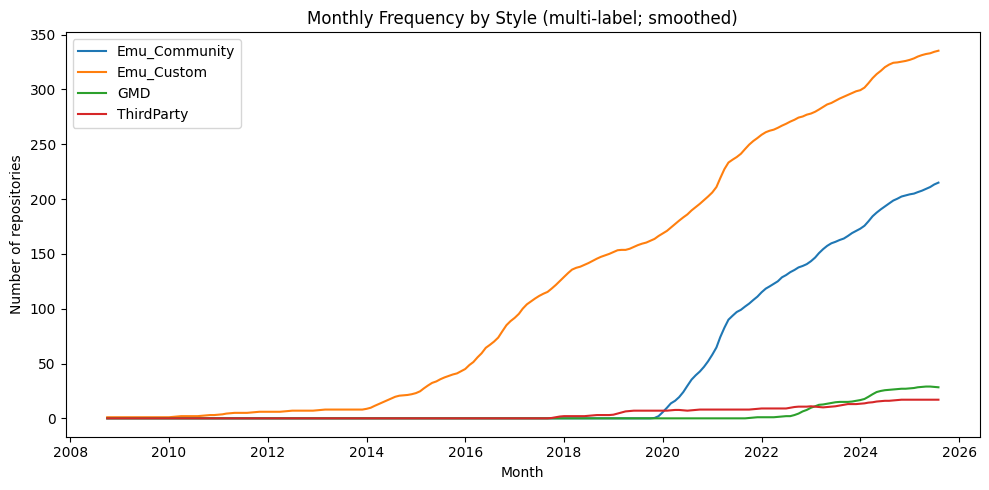

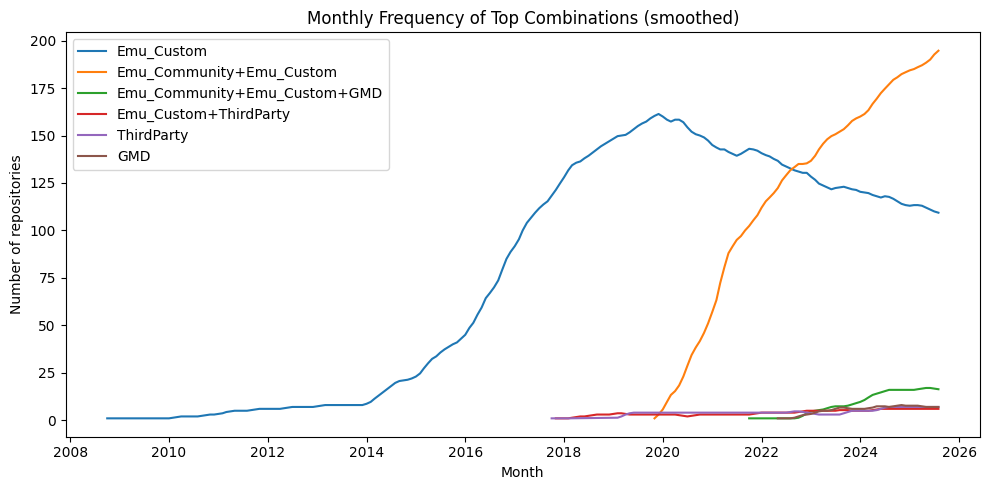

In [6]:
# === Observation 3.2 — Frequency Trends (no files saved) ===
# Plots:
#   (A) Monthly counts by style (multi-label; NO "Both")
#   (B) Monthly counts for top-6 style combinations (mixes)
# Gaps are excluded by construction: a repo only counts in a month if a ≥14-day episode overlaps that month.

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Set
import json
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths (EDIT if your miner output folder is different) ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.0"

# ---------- Settings ----------
CUTOFF_ISO = "2025-08-10 23:59:59 +0000"
PERSIST_DAYS = 14.0
TRACKED = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
SMOOTH_ROLLING = 3   # set to 1 to disable smoothing

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def label_combo(style_set: Set[str]) -> str:
    xs = sorted([s for s in style_set if s in TRACKED])
    return "+".join(xs) if xs else ""

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_set = set(s for s in (r.get("styles") or []) if s in TRACKED)
        end = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else parse_iso(CUTOFF_ISO)
        end = min(end or parse_iso(CUTOFF_ISO), parse_iso(CUTOFF_ISO))
        if end <= start:
            continue
        eps.append({
            "start": start, "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

def filter_active(eps: List[Dict], min_days: float) -> List[Dict]:
    return [ep for ep in eps if ep["duration_days"] >= min_days and len(ep["styles"]) > 0]

def month_range(start: datetime, end: datetime) -> List[pd.Timestamp]:
    s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
    e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
    rng = pd.period_range(s, e, freq="M").to_timestamp(how="start")
    if len(rng) == 0 and end > start:
        rng = pd.to_datetime([s])
    return list(rng)

# ---------- Load + build per-repo monthly states ----------
CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {OUTPUT_MINE}")

repo_eps: Dict[str, List[Dict]] = {}
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps = build_episodes(data.get("timeline") or [], CUTOFF_DT)
    eps = filter_active(eps, PERSIST_DAYS)
    repo_eps[repo] = eps

global_months: Set[pd.Timestamp] = set()
monthly_rows: List[Dict] = []

for repo, eps in repo_eps.items():
    if eps:
        start_min = min(ep["start"] for ep in eps)
        end_max = max(ep["end"] for ep in eps)
        months = month_range(start_min, end_max)
    else:
        months = []
    for m in months:
        global_months.add(m)
        m_start = m.tz_localize("UTC")
        m_end = (m + pd.offsets.MonthBegin(1)).tz_localize("UTC")
        styles_active: Set[str] = set()
        for ep in eps:
            if ep["start"] < m_end and ep["end"] > m_start:
                styles_active |= ep["styles"]
        monthly_rows.append({
            "repo_name": repo,
            "month": m,
            "combo": label_combo(styles_active),
            "Emu_Community": 1 if "Emu_Community" in styles_active else 0,
            "Emu_Custom": 1 if "Emu_Custom" in styles_active else 0,
            "GMD": 1 if "GMD" in styles_active else 0,
            "ThirdParty": 1 if "ThirdParty" in styles_active else 0,
        })

dfm = pd.DataFrame(monthly_rows).sort_values(["month","repo_name"]).reset_index(drop=True)
months_sorted = sorted(global_months)
if not months_sorted:
    raise RuntimeError("No months detected—check mined data and cutoff.")

# (A) Per-style monthly frequency (multi-label; no "Both")
styles = ["Emu_Community","Emu_Custom","GMD","ThirdParty"]
style_counts = (
    dfm.groupby("month")[styles]
       .sum()
       .reset_index()
       .melt(id_vars="month", var_name="style", value_name="count")
       .sort_values(["month","style"])
)

if SMOOTH_ROLLING > 1:
    style_counts["count_smooth"] = (
        style_counts.groupby("style")["count"]
        .transform(lambda s: s.rolling(window=SMOOTH_ROLLING, min_periods=1).mean())
    )
else:
    style_counts["count_smooth"] = style_counts["count"]

# (B) Combination monthly frequency (mixes)
combo_counts = (
    dfm[dfm["combo"] != ""]
      .groupby(["month","combo"])
      .size()
      .reset_index(name="count")
      .sort_values(["month","count"], ascending=[True, False])
)

if SMOOTH_ROLLING > 1:
    combo_counts["count_smooth"] = (
        combo_counts.groupby("combo")["count"]
        .transform(lambda s: s.rolling(window=SMOOTH_ROLLING, min_periods=1).mean())
    )
else:
    combo_counts["count_smooth"] = combo_counts["count"]

top6 = (combo_counts.groupby("combo")["count"].sum()
        .sort_values(ascending=False).head(6).index.tolist())

# ---------- DISPLAY PLOTS ----------
plt.figure(figsize=(10, 5))
for sty in styles:
    sub = style_counts[style_counts["style"] == sty]
    plt.plot(sub["month"], sub["count_smooth"], label=sty)
plt.title("Monthly Frequency by Style (multi-label; smoothed)")
plt.xlabel("Month")
plt.ylabel("Number of repositories")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for cmb in top6:
    sub = combo_counts[combo_counts["combo"] == cmb]
    plt.plot(sub["month"], sub["count_smooth"], label=cmb)
plt.title("Monthly Frequency of Top Combinations (smoothed)")
plt.xlabel("Month")
plt.ylabel("Number of repositories")
plt.legend()
plt.tight_layout()
plt.show()


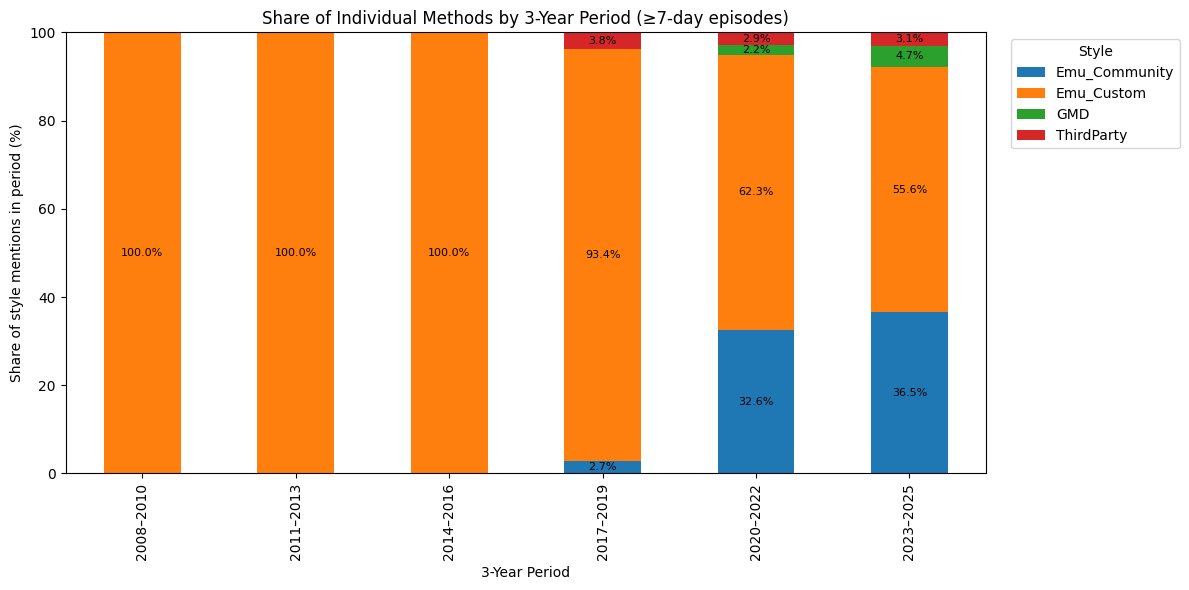

In [27]:
# === Stacked Bar Plot with On-Bar Percentage Labels (3-year buckets, tz-safe) ===
# • Buckets: 2008–2010, 2011–2013, …, 2023–2025
# • Stack shows share (%) of individual methods within each bucket
# • Each segment is labeled with its percentage for that bucket
# • ≥14-day persistence; gap months excluded; multi-label counting
# • TZ-safe month handling (no Period conversions -> no tz warning)

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Set
import json
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.0"

# ---------- Settings ----------
CUTOFF_ISO = "2025-08-10 23:59:59 +0000"
PERSIST_DAYS = 1.0
STYLES = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")
YEAR_START, YEAR_END = 2008, 2025
BUCKET_SIZE = 3  # years per bucket

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    """Parse ISO-ish string to timezone-aware UTC datetime."""
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    # normalize +0000 -> +00:00
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def build_episodes(timeline_rows: List[Dict], cutoff_dt: datetime) -> List[Dict]:
    """Contiguous active-style episodes from non-empty timeline rows, capped at cutoff."""
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles")),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        styles_set = set(s for s in (r.get("styles") or []) if s in STYLES)
        end = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else parse_iso(CUTOFF_ISO)
        end = min(end or parse_iso(CUTOFF_ISO), parse_iso(CUTOFF_ISO))
        if end <= start:
            continue
        eps.append({
            "start": start, "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

def filter_active(eps: List[Dict], min_days: float) -> List[Dict]:
    """Keep episodes that persist ≥ min_days and include at least one tracked style."""
    return [ep for ep in eps if ep["duration_days"] >= min_days and len(ep["styles"]) > 0]

def month_range(start: datetime, end: datetime) -> List[pd.Timestamp]:
    """
    Return a list of naive (tz-less) month-start Timestamps covering [start, end].
    TZ-safe: convert to UTC and strip tz; avoid Period conversions (no tz warnings).
    """
    s = pd.Timestamp(start)
    e = pd.Timestamp(end)
    if s.tzinfo is not None:
        s = s.tz_convert('UTC').tz_localize(None)
    if e.tzinfo is not None:
        e = e.tz_convert('UTC').tz_localize(None)
    s = pd.Timestamp(s.year, s.month, 1)
    e = pd.Timestamp(e.year, e.month, 1)
    months = pd.date_range(start=s, end=e, freq='MS')
    if len(months) == 0 and pd.Timestamp(end) > pd.Timestamp(start):
        months = pd.DatetimeIndex([s])
    return list(months)

def bucket_label(year: int) -> str:
    """Map a year to its 3-year bucket label, e.g., 2008→'2008–2010'."""
    k = (year - YEAR_START) // BUCKET_SIZE
    y0 = YEAR_START + k * BUCKET_SIZE
    y1 = min(y0 + BUCKET_SIZE - 1, YEAR_END)
    return f"{y0}–{y1}"

# ---------- Build monthly activity (gaps excluded by construction) ----------
CUTOFF_DT = parse_iso(CUTOFF_ISO)
assert CUTOFF_DT is not None, "Bad CUTOFF_ISO"

json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {OUTPUT_MINE}")

rows = []
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps = filter_active(build_episodes(data.get("timeline") or [], CUTOFF_DT), PERSIST_DAYS)
    if not eps:
        continue
    start_min = min(ep["start"] for ep in eps)
    end_max = max(ep["end"] for ep in eps)
    months = month_range(start_min, end_max)
    for m in months:
        # m is naive month-start; convert to UTC for overlap checks
        m_start = m.tz_localize("UTC")
        m_end = (m + pd.offsets.MonthBegin(1)).tz_localize("UTC")
        styles_active: Set[str] = set()
        for ep in eps:
            if ep["start"] < m_end and ep["end"] > m_start:
                styles_active |= ep["styles"]
        if styles_active:
            rows.append({
                "repo_name": repo,
                "month": m,
                **{s: (1 if s in styles_active else 0) for s in STYLES}
            })

dfm = pd.DataFrame(rows).sort_values(["month","repo_name"]).reset_index(drop=True)
if dfm.empty:
    raise RuntimeError("No data to plot after applying ≥14-day rule. Check miner outputs and CUTOFF_ISO.")

# ---------- Aggregate to 3-year buckets ----------
dfm["bucket"] = dfm["month"].dt.year.map(bucket_label)

# For each bucket: count repos per style (repo counted once per style if it appears in ANY month of the bucket)
style_bucket_counts = (
    dfm.groupby(["bucket","repo_name"])[list(STYLES)]
       .max()                      # repo-level within bucket: did it ever use style?
       .reset_index()
       .groupby("bucket")[list(STYLES)]
       .sum()                      # number of repos per style in bucket
       .sort_index()
)

# Convert to shares that sum to 100% per bucket (normalize by total style mentions in bucket)
tot_mentions = style_bucket_counts.sum(axis=1).replace(0, pd.NA)
style_bucket_shares = (style_bucket_counts.T / tot_mentions).T.fillna(0.0) * 100.0

# ---------- Plot: Stacked bars with percentage labels ----------
ax = style_bucket_shares.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Share of Individual Methods by 3-Year Period (≥7-day episodes)")
ax.set_xlabel("3-Year Period")
ax.set_ylabel("Share of style mentions in period (%)")
ax.set_ylim(0, 100)
ax.legend(title="Style", bbox_to_anchor=(1.02, 1), loc="upper left")

# Add on-bar percentage labels for each stack segment (centered)
buckets = style_bucket_shares.index.tolist()
cols = style_bucket_shares.columns.tolist()
for i, bucket in enumerate(buckets):
    cum = 0.0
    for sty in cols:
        val = float(style_bucket_shares.loc[bucket, sty])
        if val <= 0.0:
            continue
        y_center = cum + val / 2.0
        ax.text(i, y_center, f"{val:.1f}%", ha="center", va="center", fontsize=8)
        cum += val

plt.tight_layout()
plt.show()


In [34]:
# === RQ3 Opening Stats: Basic Episode Facts & ≥14-day Exclusions ===
# - Total change episodes across all repos
# - Episodes with ≥1 tracked style (Emu_Community / Emu_Custom / GMD / ThirdParty)
# - Episodes excluded by the ≥14-day rule and affected repos

from __future__ import annotations
from pathlib import Path
from datetime import datetime, timezone
from typing import Dict, List, Optional, Set
import json
import pandas as pd

# ---------- Paths ----------
WORK_ROOT_MINED = Path(r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ3")
OUTPUT_MINE = WORK_ROOT_MINED / "mineV9.0"

# ---------- Settings ----------
CUTOFF_ISO   = "2025-08-10 23:59:59 +0000"
PERSIST_MIN  = 14  # episodes shorter than this are considered excluded
STYLES       = ("Emu_Community", "Emu_Custom", "GMD", "ThirdParty")

# ---------- Helpers ----------
def parse_iso(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = s.strip()
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    if len(s) >= 5 and (s[-5] in ["+","-"]) and s[-3] != ":":
        s = s[:-2] + ":" + s[-2:]
    try:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt.astimezone(timezone.utc)
    except Exception:
        return None

def days_between(a: datetime, b: datetime) -> float:
    return (b - a).total_seconds() / 86400.0

def read_repo_jsons(out_dir: Path) -> List[Path]:
    return sorted([p for p in out_dir.glob("*.emulator_timeline.json") if p.name != "index_summary.json"])

def build_episodes(timeline_rows: List[Dict], cutoff_iso: str) -> List[Dict]:
    """Build contiguous episodes from non-empty timeline rows; each episode has [start,end), styles, duration_days."""
    cutoff_dt = parse_iso(cutoff_iso)
    rows = sorted(
        (r for r in (timeline_rows or []) if r.get("styles") is not None),
        key=lambda r: parse_iso(r.get("date")) or datetime.min.replace(tzinfo=timezone.utc)
    )
    eps: List[Dict] = []
    for i, r in enumerate(rows):
        start = parse_iso(r.get("date"))
        if start is None:
            continue
        # Keep only tracked styles; may become empty if row had other kinds of styles
        styles_set = set(s for s in (r.get("styles") or []) if s in STYLES)
        nxt = parse_iso(rows[i+1].get("date")) if (i + 1) < len(rows) else cutoff_dt
        end = min(nxt or cutoff_dt, cutoff_dt)
        if end <= start:
            continue
        eps.append({
            "start": start,
            "end": end,
            "styles": styles_set,
            "duration_days": max(0.0, days_between(start, end)),
        })
    return eps

# ---------- Load all repos & assemble episode table ----------
json_files = read_repo_jsons(OUTPUT_MINE)
if not json_files:
    raise FileNotFoundError(f"No miner JSONs found in {OUTPUT_MINE}")

episode_rows = []
for jf in json_files:
    with jf.open("r", encoding="utf-8") as f:
        data = json.load(f)
    repo = data.get("repo_name") or jf.stem
    eps = build_episodes(data.get("timeline") or [], CUTOFF_ISO)
    for ep in eps:
        episode_rows.append({
            "repo_name": repo,
            "start": ep["start"],
            "end": ep["end"],
            "duration_days": ep["duration_days"],
            "has_tracked_style": 1 if (ep["styles"] and len(ep["styles"]) > 0) else 0,
            # style flags for convenience (multi-label)
            **{s: (1 if (ep["styles"] and s in ep["styles"]) else 0) for s in STYLES}
        })

episodes_df = pd.DataFrame(episode_rows).sort_values(["start","repo_name"]).reset_index(drop=True)

# If there are no episodes at all (unlikely), stop here
if episodes_df.empty:
    print("No episodes detected across repos. Check miner outputs.")
else:
    # ---------- Basic totals ----------
    total_eps = len(episodes_df)
    repos_with_any_eps = episodes_df["repo_name"].nunique()

    eps_with_style = episodes_df[episodes_df["has_tracked_style"] == 1]
    total_eps_with_style = len(eps_with_style)
    repos_with_style_eps = eps_with_style["repo_name"].nunique()

    # ---------- Exclusions under ≥14-day rule (only episodes that have tracked styles) ----------
    excluded = eps_with_style[eps_with_style["duration_days"] < PERSIST_MIN]
    excluded_eps = len(excluded)
    repos_with_excluded = excluded["repo_name"].nunique()

    # ---------- Print summary ----------
    print("=== RQ3 Opening Facts (Episodes & ≥14-day Exclusions) ===")
    print(f"Total change episodes (all kinds): {total_eps}  across {repos_with_any_eps} repos")
    print(f"Episodes with ≥1 tracked style:    {total_eps_with_style}  across {repos_with_style_eps} repos")
    print(f"Excluded by ≥14-day rule:         {excluded_eps}  episodes  across {repos_with_excluded} repos")

    # Helpful extras
    if total_eps_with_style > 0:
        print("\nDuration stats for episodes WITH tracked styles (days):")
        print(eps_with_style["duration_days"].describe().round(2))

    if excluded_eps > 0:
        print("\nDuration stats for EXCLUDED episodes (duration < 14 days):")
        print(excluded["duration_days"].describe().round(2))

        # Per-style counts among excluded (multi-label: an episode can count to multiple styles)
        # Ensure columns exist
        for s in STYLES:
            if s not in excluded.columns:
                excluded[s] = 0
        print("\nExcluded episodes per style (multi-label counts):")
        print(excluded[list(STYLES)].sum().astype(int))


=== RQ3 Opening Facts (Episodes & ≥14-day Exclusions) ===
Total change episodes (all kinds): 954  across 350 repos
Episodes with ≥1 tracked style:    954  across 350 repos
Excluded by ≥14-day rule:         380  episodes  across 41 repos

Duration stats for episodes WITH tracked styles (days):
count     954.00
mean      805.99
std      1122.39
min         0.00
25%         1.25
50%       154.40
75%      1410.98
max      5328.18
Name: duration_days, dtype: float64

Duration stats for EXCLUDED episodes (duration < 14 days):
count    380.00
mean       2.13
std        3.13
min        0.00
25%        0.07
50%        0.81
75%        2.89
max       13.78
Name: duration_days, dtype: float64

Excluded episodes per style (multi-label counts):
Emu_Community    163
Emu_Custom       372
GMD               12
ThirdParty        25
dtype: int64
